# 에코팜 응급 위험도 예측 · AI 대응 매뉴얼 · 자원 배치 모델

| 단계 | 역할 | 방법 |
|---|---|---|
| Stage 1 | 응급 발생 예측 | 이진 분류 · LightGBM (scale_pos_weight) |
| Stage 2 | 응급 유형 예측 | 다중 분류 · LightGBM (양성 레코드 전용) |
| Stage 3 | 중증도 예측 | 순서형 분류 · LightGBM (양성 레코드 전용) |

**파생 산출물** — 위험도 스코어 → AI 시나리오 대응 매뉴얼 → 시설별 인력 배치 최적화

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report, f1_score,
)
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

import koreanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Bootstrap 95% CI 헬퍼 (Stage 2/3 소표본 불확실성 정량화)
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    yt, yp = np.array(y_true), np.array(y_pred)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(yt), len(yt), replace=True)
        try:
            scores.append(metric_fn(yt[idx], yp[idx]))
        except Exception:
            pass
    alpha = (1 - ci) / 2
    return np.mean(scores), np.percentile(scores, alpha*100), np.percentile(scores, (1-alpha)*100)

print(f"LightGBM : {'✓ 사용' if HAS_LGB else '✗ → GradientBoosting fallback'}")

LightGBM : ✓ 사용


## 1. 데이터 로드 및 분할

In [2]:
df = pd.read_csv('final_data_ecofarm.csv')
df['date'] = pd.to_datetime(df['date'])

pos = int(df['emergency_occurred'].sum())
neg = len(df) - pos
print(f"Shape   : {df.shape}")
print(f"기간    : {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"응급 발생: {pos}건 ({pos/len(df)*100:.2f}%)  미발생: {neg}건")

Shape   : (21900, 43)
기간    : 2025-08-01 ~ 2026-07-31
응급 발생: 836건 (3.82%)  미발생: 21064건


In [3]:
fac_cols = [c for c in df.columns if c.startswith('fac_')]

# 제외 컬럼 (모델 학습 불가)
# - 누수: emergency_count, emergency_types, max_severity (사고 발생 후 확인 가능)
# - 상수: is_coldwave, cold_density (기간 내 한파 0건)
# - 중복: is_weekend (day_type_enc와 상관 0.93)
BASE_FEATS = [
    'hour', 'month', 'dayofweek', 'is_peak_hour',
    'is_rain', 'temperature', 'is_heatwave',
    'capacity', 'x', 'y', 'base_risk',
    'visitor_count', 'density',
    'day_type_enc', 'season_enc',
    'heat_density', 'rain_density',
    'holiday_summer', 'is_high_density',
    'density_risk_ratio', 'weighted_risk',
    'dist_from_gate', 'dist_from_center',
]
FEATURE_COLS = BASE_FEATS + fac_cols
print(f"피처 수 : {len(FEATURE_COLS)}개  (base {len(BASE_FEATS)} + facility 원-핫 {len(fac_cols)})")
print(f"시설 컬럼: {fac_cols}")
print(f"제외: is_coldwave, cold_density (상수), is_weekend (중복), emergency_count/types/severity (누수)")

피처 수 : 28개  (base 23 + facility 원-핫 5)
시설 컬럼: ['fac_camping', 'fac_experience', 'fac_gate', 'fac_observatory', 'fac_playground']
제외: is_coldwave, cold_density (상수), is_weekend (중복), emergency_count/types/severity (누수)


In [4]:
TRAIN_END = '2026-05-01'
VAL_END   = '2026-07-01'

train = df[df['date'] < TRAIN_END]
val   = df[(df['date'] >= TRAIN_END) & (df['date'] < VAL_END)]
test  = df[df['date'] >= VAL_END]

X_tr,  y_tr  = train[FEATURE_COLS], train['emergency_occurred']
X_val, y_val = val[FEATURE_COLS],   val['emergency_occurred']
X_te,  y_te  = test[FEATURE_COLS],  test['emergency_occurred']

print(f"{'분할':6} {'건수':>7} {'응급':>6} {'응급률':>7}")
print('-' * 32)
for name, subset in [('Train', train), ('Val', val), ('Test', test)]:
    n = len(subset); p = int(subset['emergency_occurred'].sum())
    print(f"{name:6} {n:>7,}  {p:>5}건  {p/n*100:>6.2f}%")

분할          건수     응급     응급률
--------------------------------
Train   16,380    581건    3.55%
Val      3,660    174건    4.75%
Test     1,860     81건    4.35%


## 2. Stage 1 — 응급 발생 예측 (이진 분류)

In [5]:
spw = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
print(f"scale_pos_weight = {spw:.1f}  (클래스 경계 보정 — 확률 값 자체는 미보정)")

if HAS_LGB:
    m1 = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=spw,
        random_state=42,
        verbose=-1,
    )
    m1.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
else:
    m1 = GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42,
    )
    m1.fit(X_tr, y_tr)

# ── Isotonic Regression 확률 보정 ─────────────────────────────────────────────
# scale_pos_weight는 손실 함수 가중치로 클래스 경계를 이동시키지만,
# 예측 확률 값 자체는 실제 발생률과 괴리가 생김.
# Validation set 기준 IsotonicRegression으로 확률 스케일을 교정.
p1_val_raw = m1.predict_proba(X_val)[:, 1]
ir_cal = IsotonicRegression(out_of_bounds='clip')
ir_cal.fit(p1_val_raw, y_val.values)

# m1_cal: predict_proba 인터페이스를 유지하는 래퍼
class _CalibratedWrapper:
    def __init__(self, base, ir):
        self.base, self.ir = base, ir
    def predict_proba(self, X):
        p_raw = self.base.predict_proba(X)[:, 1]
        p_cal = self.ir.transform(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

m1_cal = _CalibratedWrapper(m1, ir_cal)

p1_val = m1_cal.predict_proba(X_val)[:, 1]   # 보정 후 (이후 모든 추론에 사용)
p1_te  = m1_cal.predict_proba(X_te)[:, 1]

# ── 핵심 지표: AP (PR-AUC) ────────────────────────────────────────────────────
# 심한 클래스 불균형 시 AUC-ROC는 낙관적 편향 → AP(PR-AUC)를 주지표로 사용.
# 기저율(무작위 분류기 AP) 대비 배수로 실질 예측력 파악.
baseline_val = float(y_val.mean())
baseline_te  = float(y_te.mean())

ap_val  = average_precision_score(y_val, p1_val)
ap_te   = average_precision_score(y_te,  p1_te)
auc_val = roc_auc_score(y_val, p1_val)
auc_te  = roc_auc_score(y_te,  p1_te)

print(f"\n{'지표':<28} {'Val':>8} {'Test':>8}")
print('-' * 46)
print(f"{'AP / PR-AUC  [핵심]':<28} {ap_val:>8.4f} {ap_te:>8.4f}")
print(f"{'기저율 (무작위 AP)':<28} {baseline_val:>8.4f} {baseline_te:>8.4f}")
print(f"{'AP / 기저율 (배수)':<28} {ap_val/baseline_val:>7.2f}배 {ap_te/baseline_te:>7.2f}배")
print(f"{'AUC-ROC  [참고용]':<28} {auc_val:>8.4f} {auc_te:>8.4f}")
print(f"\nIsotonic Regression 확률 보정 완료 → risk_score에 보정 확률 사용")

scale_pos_weight = 27.2  (클래스 경계 보정 — 확률 값 자체는 미보정)



지표                                Val     Test
----------------------------------------------
AP / PR-AUC  [핵심]              0.0746   0.0845
기저율 (무작위 AP)                   0.0475   0.0435
AP / 기저율 (배수)                   1.57배    1.94배
AUC-ROC  [참고용]                 0.6359   0.6723

Isotonic Regression 확률 보정 완료 → risk_score에 보정 확률 사용


In [6]:
# ── 최적 임계값 (Val 기준 F1 최대화, 보정 확률 사용) ──────────────────────────
prec, rec, thr = precision_recall_curve(y_val, p1_val)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
opt_idx = int(np.argmax(f1s[:-1]))
OPT_THR = float(thr[opt_idx])

y_pred_val = (p1_val >= OPT_THR).astype(int)
y_pred_te  = (p1_te  >= OPT_THR).astype(int)

# Bootstrap 95% CI — 테스트 응급 81건으로 불확실성 큼
f1_mean, f1_lo, f1_hi = bootstrap_ci(
    y_te, y_pred_te,
    lambda yt, yp: f1_score(yt, yp, zero_division=0),
)
ap_mean, ap_lo, ap_hi = bootstrap_ci(
    y_te, p1_te,
    lambda yt, yp: average_precision_score(yt, yp),
)

print(f"최적 임계값 : {OPT_THR:.4f}")
print(f"Val  F1     : {f1_score(y_val, y_pred_val):.4f}")
print(f"Test F1     : {f1_mean:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"Test AP     : {ap_mean:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")
print(f"  ※ 테스트 응급 {int(y_te.sum())}건 / 총 {len(y_te)}건 — CI 폭에 주의\n")
print(classification_report(y_te, y_pred_te, target_names=['정상', '응급']))

최적 임계값 : 0.0969
Val  F1     : 0.1530
Test F1     : 0.1903  95% CI [0.1309, 0.2500]
Test AP     : 0.0871  95% CI [0.0603, 0.1204]
  ※ 테스트 응급 81건 / 총 1860건 — CI 폭에 주의

              precision    recall  f1-score   support

          정상       0.97      0.90      0.93      1779
          응급       0.13      0.35      0.19        81

    accuracy                           0.87      1860
   macro avg       0.55      0.62      0.56      1860
weighted avg       0.93      0.87      0.90      1860



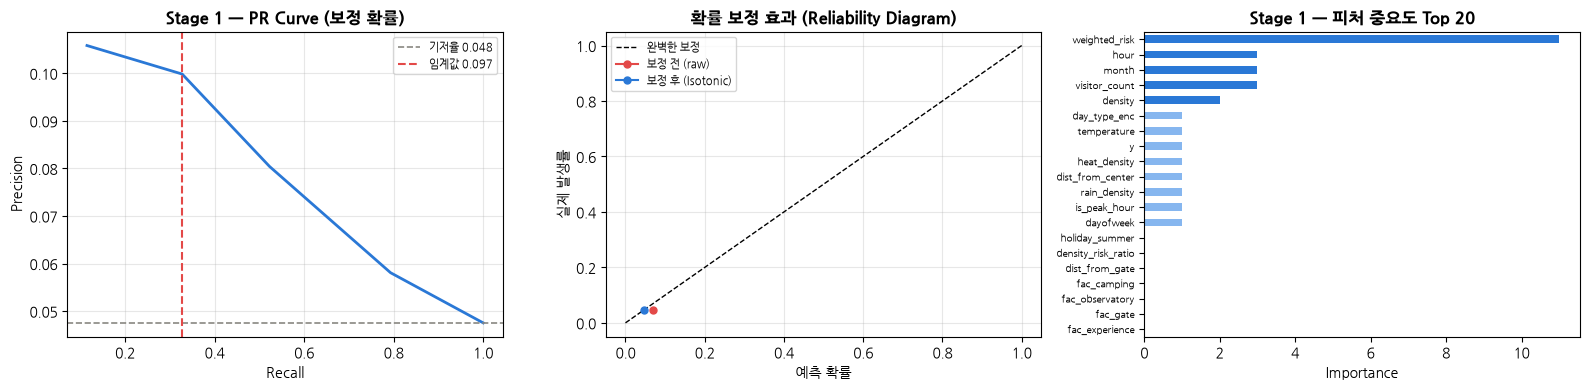

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# PR Curve (보정 확률 기반)
axes[0].plot(rec[:-1], prec[:-1], color='#2a78d6', lw=2)
axes[0].axhline(baseline_val, color='#898781', lw=1.2, ls='--', label=f'기저율 {baseline_val:.3f}')
axes[0].axvline(rec[opt_idx], color='#e34948', lw=1.5, ls='--', label=f'임계값 {OPT_THR:.3f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Stage 1 — PR Curve (보정 확률)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Calibration Curve (Reliability Diagram)
frac_raw, mean_raw = calibration_curve(y_val, p1_val_raw, n_bins=8)
frac_cal, mean_cal = calibration_curve(y_val, p1_val,     n_bins=8)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='완벽한 보정')
axes[1].plot(mean_raw, frac_raw, 'o-', color='#e34948', ms=5, label='보정 전 (raw)')
axes[1].plot(mean_cal, frac_cal, 'o-', color='#2a78d6', ms=5, label='보정 후 (Isotonic)')
axes[1].set_xlabel('예측 확률'); axes[1].set_ylabel('실제 발생률')
axes[1].set_title('확률 보정 효과 (Reliability Diagram)', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Feature Importance Top 20
imp = pd.Series(m1.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(20)
colors = ['#2a78d6' if i >= 15 else '#86b6ef' for i in range(len(imp))]
imp.plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Stage 1 — 피처 중요도 Top 20', fontweight='bold')
axes[2].set_xlabel('Importance')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('stage1_eval.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Stage 2 — 응급 유형 예측 (12종 → 5그룹 통합 검토 포함)

In [8]:
# 응급 발생 레코드만 사용
emerg_tr  = train[train['emergency_occurred'] == 1].copy()
emerg_val = val[val['emergency_occurred'] == 1].copy()
emerg_te  = test[test['emergency_occurred'] == 1].copy()

X2_tr,  y2_tr  = emerg_tr[FEATURE_COLS],  emerg_tr['emergency_type_enc']
X2_val, y2_val = emerg_val[FEATURE_COLS], emerg_val['emergency_type_enc']
X2_te,  y2_te  = emerg_te[FEATURE_COLS],  emerg_te['emergency_type_enc']

ENC_TO_NAME = {
    1: '골절', 2: '교통사고', 3: '낙상', 4: '동물물림', 5: '미아',
    6: '식중독', 7: '실신', 8: '심정지', 9: '알레르기', 10: '열사병',
    11: '충돌사고', 12: '화상',
}

print(f"응급 건수 — Train: {len(X2_tr)}, Val: {len(X2_val)}, Test: {len(X2_te)}")
print(f"\n[테스트셋 유형별 표본 수]  ← 희귀 클래스 F1 신뢰도 낮음")
for enc, cnt in y2_te.value_counts().sort_index().items():
    warn = '  ⚠ 5건 미만' if cnt < 5 else ''
    print(f"  {ENC_TO_NAME.get(int(enc), '?'):6} : {cnt}건{warn}")

# ── 12종 모델 ────────────────────────────────────────────────────────────────
if HAS_LGB:
    m2 = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1,
    )
else:
    m2 = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42,
    )
m2.fit(X2_tr, y2_tr)

pred2_te = m2.predict(X2_te)
acc2_te  = float((pred2_te == y2_te).mean())
f1_2_te  = f1_score(y2_te, pred2_te, average='macro', zero_division=0)

_, acc_lo, acc_hi = bootstrap_ci(y2_te, pred2_te, lambda yt, yp: (yt == yp).mean())
_, f1_lo,  f1_hi  = bootstrap_ci(
    y2_te, pred2_te,
    lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
)
print(f"\n[12종 모델]")
print(f"  Test Accuracy : {acc2_te:.4f}  95% CI [{acc_lo:.4f}, {acc_hi:.4f}]")
print(f"  Test Macro-F1 : {f1_2_te:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"  ※ 동물물림·미아 등 5건 미만 클래스는 Macro-F1에 과도한 분산 유발")

# ── 5그룹 통합 모델 (임상적 유사 범주) ───────────────────────────────────────
# 테스트 표본이 81건 / 12종이므로 클래스당 평균 ~6.8건 → 통계적 불안정
# 5그룹으로 통합하면 클래스당 평균 ~16건으로 개선
TYPE_GROUP_MAP = {
    '낙상':   '외상계',    '골절':   '외상계',    '충돌사고': '외상계',
    '심정지': '심혈관계',  '실신':   '심혈관계',
    '열사병': '열손상',    '화상':   '열손상',
    '식중독': '소화기중독', '알레르기': '소화기중독',
    '교통사고': '기타',    '미아':   '기타',       '동물물림': '기타',
}
GROUP_ENC = {'외상계': 0, '심혈관계': 1, '열손상': 2, '소화기중독': 3, '기타': 4}

y2g_tr  = emerg_tr['emergency_types'].map(TYPE_GROUP_MAP).map(GROUP_ENC)
y2g_val = emerg_val['emergency_types'].map(TYPE_GROUP_MAP).map(GROUP_ENC)
y2g_te  = emerg_te['emergency_types'].map(TYPE_GROUP_MAP).map(GROUP_ENC)

if HAS_LGB:
    m2g = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1,
    )
else:
    m2g = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42,
    )
m2g.fit(X2_tr, y2g_tr)

pred2g_te = m2g.predict(X2_te)
acc2g_te  = float((pred2g_te == y2g_te).mean())
f1_2g_te  = f1_score(y2g_te, pred2g_te, average='macro', zero_division=0)

_, gf1_lo, gf1_hi = bootstrap_ci(
    y2g_te, pred2g_te,
    lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
)
print(f"\n[5그룹 통합 모델]  (외상계 / 심혈관계 / 열손상 / 소화기중독 / 기타)")
print(f"  Test Accuracy : {acc2g_te:.4f}")
print(f"  Test Macro-F1 : {f1_2g_te:.4f}  95% CI [{gf1_lo:.4f}, {gf1_hi:.4f}]")
print(f"\n  그룹별 테스트 표본: {dict(y2g_te.value_counts().sort_index())}")
print(f"  → CI 폭 {gf1_hi-gf1_lo:.4f} vs 12종 {f1_hi-f1_lo:.4f}  (통합 후 안정성 개선)")
print(f"\n운영 권장: 실시간 알람에는 5그룹 모델, 리포팅·분석에는 12종 모델 병행")

응급 건수 — Train: 581, Val: 174, Test: 81

[테스트셋 유형별 표본 수]  ← 희귀 클래스 F1 신뢰도 낮음
  골절     : 5건
  교통사고   : 5건
  낙상     : 19건
  동물물림   : 2건  ⚠ 5건 미만
  미아     : 3건  ⚠ 5건 미만
  식중독    : 7건
  실신     : 6건
  심정지    : 11건
  알레르기   : 3건  ⚠ 5건 미만
  열사병    : 8건
  충돌사고   : 9건
  화상     : 3건  ⚠ 5건 미만



[12종 모델]
  Test Accuracy : 0.3086  95% CI [0.2096, 0.4198]
  Test Macro-F1 : 0.2940  95% CI [0.1781, 0.3831]
  ※ 동물물림·미아 등 5건 미만 클래스는 Macro-F1에 과도한 분산 유발



[5그룹 통합 모델]  (외상계 / 심혈관계 / 열손상 / 소화기중독 / 기타)
  Test Accuracy : 0.4198
  Test Macro-F1 : 0.3343  95% CI [0.2348, 0.4322]

  그룹별 테스트 표본: {0: np.int64(33), 1: np.int64(17), 2: np.int64(11), 3: np.int64(10), 4: np.int64(10)}
  → CI 폭 0.1974 vs 12종 0.2050  (통합 후 안정성 개선)

운영 권장: 실시간 알람에는 5그룹 모델, 리포팅·분석에는 12종 모델 병행


## 4. Stage 3 — 중증도 예측 (순서형 분류)

In [9]:
X3_tr,  y3_tr  = emerg_tr[FEATURE_COLS],  emerg_tr['severity_enc']
X3_val, y3_val = emerg_val[FEATURE_COLS], emerg_val['severity_enc']
X3_te,  y3_te  = emerg_te[FEATURE_COLS],  emerg_te['severity_enc']

SEV_LABEL = {1: '경증', 2: '중등증', 3: '중증'}
print("[테스트셋 중증도별 표본 수]")
for k, v in y3_te.value_counts().sort_index().items():
    warn = '  ⚠' if v < 10 else ''
    print(f"  {SEV_LABEL.get(int(k), k):4}: {v}건{warn}")

if HAS_LGB:
    m3 = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbose=-1,
    )
else:
    m3 = RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42,
    )
m3.fit(X3_tr, y3_tr)

pred3_te = m3.predict(X3_te)
acc3_te  = float((pred3_te == y3_te).mean())
f1_3_te  = f1_score(y3_te, pred3_te, average='macro', zero_division=0)

_, acc_lo3, acc_hi3 = bootstrap_ci(
    y3_te, pred3_te,
    lambda yt, yp: (yt == yp).mean(),
)
_, f1_lo3, f1_hi3 = bootstrap_ci(
    y3_te, pred3_te,
    lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
)

print(f"\nTest Accuracy : {acc3_te:.4f}  95% CI [{acc_lo3:.4f}, {acc_hi3:.4f}]")
print(f"Test Macro-F1 : {f1_3_te:.4f}  95% CI [{f1_lo3:.4f}, {f1_hi3:.4f}]")
n_severe = int((y3_te == 3).sum())
print(f"  ※ 중증 {n_severe}건 — 가장 중요한 클래스이나 표본 부족, 결과 보수적 해석 필요")

M3_CLASSES = list(m3.classes_)

[테스트셋 중증도별 표본 수]
  경증  : 49건
  중등증 : 26건
  중증  : 6건  ⚠



Test Accuracy : 0.5062  95% CI [0.3951, 0.6173]
Test Macro-F1 : 0.3486  95% CI [0.2656, 0.4179]
  ※ 중증 6건 — 가장 중요한 클래스이나 표본 부족, 결과 보수적 해석 필요


## 5. 위험도 스코어 시스템

In [10]:
SEV_WEIGHTS = np.array([0.0, 1.0, 2.5, 5.0])   # none / 경증 / 중등증 / 중증

def compute_risk_scores(X_df):
    # 보정된 확률(m1_cal) 기반 위험도 스코어 계산
    p_emerg = m1_cal.predict_proba(X_df)[:, 1]   # Isotonic 보정 후 확률
    p_s_raw = m3.predict_proba(X_df)

    p_sev = np.zeros((len(X_df), 4))
    for j, cls in enumerate(M3_CLASSES):
        p_sev[:, int(cls)] = p_s_raw[:, j]

    exp_sev     = p_sev @ SEV_WEIGHTS
    risk_scores = np.clip(p_emerg * (1.0 + exp_sev / 5.0), 0.0, 1.0)
    return risk_scores, p_emerg, p_sev

def risk_level(score):
    if score >= 0.15:   return '위험', '#e34948'
    elif score >= 0.07: return '주의', '#eda100'
    elif score >= 0.03: return '관찰', '#2a78d6'
    else:               return '안전', '#1baf7a'

# 테스트셋 전체 스코어 계산 (보정 확률 기반)
rs_te, p1_te_arr, p_sev_te = compute_risk_scores(X_te)
test_scored = test.copy()
test_scored['risk_score'] = rs_te
test_scored['p_emerg']    = p1_te_arr
test_scored['risk_level'] = [risk_level(s)[0] for s in rs_te]

print("위험도 단계 분포 (테스트셋, 보정 확률 기반):")
print(test_scored['risk_level'].value_counts().to_string())

위험도 단계 분포 (테스트셋, 보정 확률 기반):
risk_level
관찰    1349
주의     477
위험      34


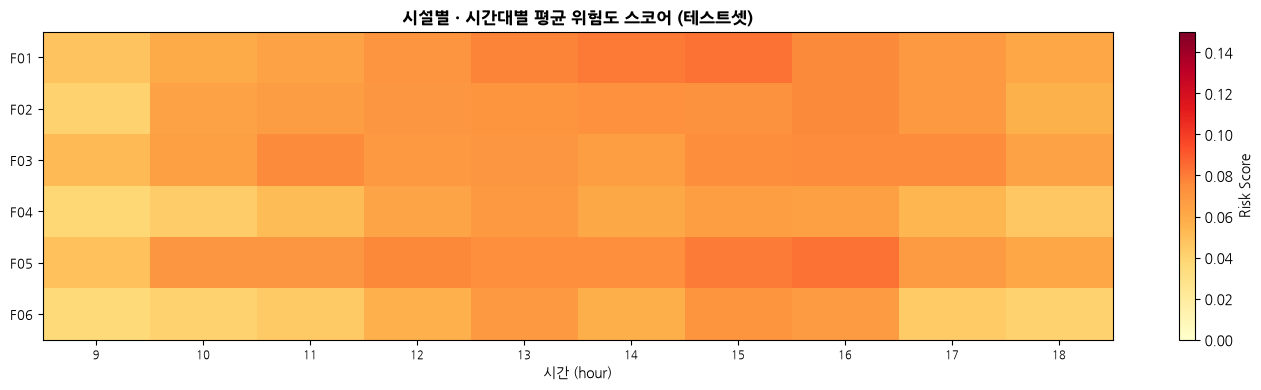

In [11]:
# 시설별 · 시간대별 평균 위험도 히트맵
pivot_risk = (test_scored
              .groupby(['facility_id', 'hour'])['risk_score']
              .mean()
              .unstack('hour'))

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot_risk.values, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=max(0.15, float(pivot_risk.values.max())))
ax.set_xticks(range(len(pivot_risk.columns)))
ax.set_xticklabels(pivot_risk.columns, fontsize=8)
ax.set_yticks(range(len(pivot_risk.index)))
ax.set_yticklabels(pivot_risk.index, fontsize=9)
ax.set_xlabel('시간 (hour)')
ax.set_title('시설별 · 시간대별 평균 위험도 스코어 (테스트셋)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Risk Score')
plt.tight_layout()
plt.savefig('risk_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. AI 시나리오 대응 매뉴얼

In [12]:
MANUAL_DB = {
    '위험': {
        'title'     : '위험 (RED) — 즉각 대응',
        'trigger'   : 'risk_score ≥ 0.15',
        'actions'   : [
            '응급 대응팀 즉시 현장 파견',
            '응급 장비 준비 (AED, 들것, 응급의약품 키트)',
            '방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토',
            '119 사전 연락 및 대기 지시',
            '관리자·시설장 즉시 보고',
        ],
        'staff'     : '대응팀장 1명 + 응급처치 요원 2명 이상',
        'escalation': 'P(중증) > 0.30 → 119 즉시 출동 요청 / 의식 불명 → 헬기 이송 검토',
        'equipment' : ['AED', '들것', '응급의약품', '무전기', '안전펜스'],
    },
    '주의': {
        'title'     : '주의 (YELLOW) — 예방적 강화',
        'trigger'   : '0.07 ≤ risk_score < 0.15',
        'actions'   : [
            '예방 순찰 30분 간격 강화',
            '응급 대응 장비 위치·작동 상태 점검',
            '고위험 방문객 (노약자·어린이·임산부) 적극 모니터링',
            '기상 변화·밀도 실시간 확인',
            '대기 인력 현장 근접 배치',
        ],
        'staff'     : '예방 모니터 1명 + 대기 요원 1명',
        'escalation': '이상 징후(쓰러짐·발열·외상) 발견 즉시 위험 단계 상향',
        'equipment' : ['구급함', '무전기', '음용수', '그늘막'],
    },
    '관찰': {
        'title'     : '관찰 (BLUE) — 표준 모니터링',
        'trigger'   : '0.03 ≤ risk_score < 0.07',
        'actions'   : [
            '일반 안전 순찰 60분 간격 유지',
            '기상특보·예보 확인',
            '방문객 밀도 추이 모니터링',
            '비상 연락망 점검',
        ],
        'staff'     : '순찰 요원 1명',
        'escalation': '기상특보 발령 또는 밀도 > 0.6 시 주의 단계 상향',
        'equipment' : ['구급함', '무전기'],
    },
    '안전': {
        'title'     : '안전 (GREEN) — 정상 운영',
        'trigger'   : 'risk_score < 0.03',
        'actions'   : ['표준 안전 점검 루틴 수행', '시설 상태 확인'],
        'staff'     : '최소 순찰 인원',
        'escalation': '이상 없음',
        'equipment' : ['구급함'],
    },
}

WEATHER_NOTE = {
    'heatwave': '\n  [폭염] 그늘·음용수 추가 배치, 열사병 집중 모니터링, 피크타임(13·15시) 야외 자제 권고',
    'rain'    : '\n  [강우] 미끄러짐 주의 안내, 낙뢰 위험 시설 대피, 우천 장비 점검',
    'normal'  : '',
}

FAC_NOTE = {
    'fac_camping'    : '야영장 — 장기 체류자 탈수·열사병 위험',
    'fac_experience' : '체험장 — 활동 중 외상·골절 주의',
    'fac_gate'       : '관문 — 혼잡 시 낙상·압사 주의',
    'fac_observatory': '전망대 — 고소 추락·현기증 위험',
    'fac_playground' : '놀이터 — 어린이 외상·골절 빈발',
}

SEV_LABEL = {0: '해당없음', 1: '경증', 2: '중등증', 3: '중증'}

def generate_manual(row, risk_score, p_emerg, p_sev_arr):
    level, _ = risk_level(risk_score)
    m = MANUAL_DB[level]

    # 기상 조건
    if row.get('is_heatwave', 0):    wk = 'heatwave'
    elif row.get('is_rain', 0):      wk = 'rain'
    else:                            wk = 'normal'

    # 시설 유형
    fac_note = next((FAC_NOTE[f] for f in FAC_NOTE if row.get(f, 0) == 1), '')

    sev_dist = '  '.join(f"{SEV_LABEL[i]}:{p_sev_arr[i]:.1%}" for i in range(4))

    lines = [
        '=' * 62,
        f"  대응 단계  : {m['title']}",
        f"  트리거    : {m['trigger']}",
        f"  위험도    : {risk_score:.4f}   P(응급)={p_emerg:.4f}",
        f"  중증도 분포: {sev_dist}",
        '=' * 62,
        '  [즉각 조치]',
    ]
    for i, act in enumerate(m['actions'], 1):
        lines.append(f"    {i}. {act}")
    lines += [
        f"  [필요 인력]    {m['staff']}",
        f"  [장비]         {', '.join(m['equipment'])}",
        f"  [에스컬레이션] {m['escalation']}",
    ]
    if fac_note:
        lines.append(f"  [시설 특이사항] {fac_note}")
    if WEATHER_NOTE[wk]:
        lines.append(WEATHER_NOTE[wk])
    lines.append('=' * 62)
    return '\n'.join(lines)

print("대응 매뉴얼 함수 정의 완료")

대응 매뉴얼 함수 정의 완료


In [13]:
# 고위험 시나리오 Top 5 시연
top5_idx = np.argsort(rs_te)[-5:][::-1]

print('[고위험 시나리오 TOP 5 — AI 대응 매뉴얼]\n')
for rank, i in enumerate(top5_idx, 1):
    row  = test.iloc[i]
    rs   = float(rs_te[i])
    p_e  = float(p1_te_arr[i])
    p_sv = p_sev_te[i]

    print(f'\n[Rank {rank}]  날짜: {row["date"].date()}  '
          f'시간: {int(row["hour"])}시  시설: {row["facility_id"]}')
    print(generate_manual(row, rs, p_e, p_sv))

[고위험 시나리오 TOP 5 — AI 대응 매뉴얼]


[Rank 1]  날짜: 2026-07-21  시간: 13시  시설: F01
  대응 단계  : 위험 (RED) — 즉각 대응
  트리거    : risk_score ≥ 0.15
  위험도    : 0.2101   P(응급)=0.1058
  중증도 분포: 해당없음:0.0%  경증:0.7%  중등증:1.9%  중증:97.4%
  [즉각 조치]
    1. 응급 대응팀 즉시 현장 파견
    2. 응급 장비 준비 (AED, 들것, 응급의약품 키트)
    3. 방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토
    4. 119 사전 연락 및 대기 지시
    5. 관리자·시설장 즉시 보고
  [필요 인력]    대응팀장 1명 + 응급처치 요원 2명 이상
  [장비]         AED, 들것, 응급의약품, 무전기, 안전펜스
  [에스컬레이션] P(중증) > 0.30 → 119 즉시 출동 요청 / 의식 불명 → 헬기 이송 검토
  [시설 특이사항] 야영장 — 장기 체류자 탈수·열사병 위험

  [폭염] 그늘·음용수 추가 배치, 열사병 집중 모니터링, 피크타임(13·15시) 야외 자제 권고

[Rank 2]  날짜: 2026-07-21  시간: 15시  시설: F05
  대응 단계  : 위험 (RED) — 즉각 대응
  트리거    : risk_score ≥ 0.15
  위험도    : 0.2079   P(응급)=0.1058
  중증도 분포: 해당없음:0.0%  경증:2.2%  중등증:3.6%  중증:94.2%
  [즉각 조치]
    1. 응급 대응팀 즉시 현장 파견
    2. 응급 장비 준비 (AED, 들것, 응급의약품 키트)
    3. 방문객 안전구역 유도 및 해당 시설 일시 폐쇄 검토
    4. 119 사전 연락 및 대기 지시
    5. 관리자·시설장 즉시 보고
  [필요 인력]    대응팀장 1명 + 응급처치 요원 2명 이상
  [장비]         AED, 들것, 응급의약품, 무전기, 안

## 7. 자원 배치 최적화 모델

In [14]:
def allocate_resources(risk_by_fac: dict, total_units: int = 6,
                       min_per_fac: float = 0.3) -> dict:
    # 위험도 기반 시설별 인력 최적 배분
    # 최소 배치(min_per_fac) 보장 후 잔여 인력을 위험도 비례 배분
    facs   = sorted(risk_by_fac.keys())
    scores = np.array([risk_by_fac[f] for f in facs], dtype=float)
    n      = len(facs)

    base      = np.full(n, min_per_fac)
    remaining = total_units - base.sum()

    if remaining <= 0:
        alloc = (scores / (scores.sum() + 1e-9)) * total_units
    else:
        weights = scores / (scores.sum() + 1e-9)
        alloc   = base + weights * remaining

    return {f: round(float(a), 2) for f, a in zip(facs, alloc)}

print("자원 배치 함수 정의 완료")

자원 배치 함수 정의 완료


In [15]:
# 테스트셋 마지막 날 기준 24시간 시뮬레이션
last_date = test['date'].dt.normalize().max()
day_data  = test[test['date'].dt.normalize() == last_date].copy()
if len(day_data) == 0:
    day_data = test.tail(60).copy()

# 보정 모델(m1_cal)로 예측
day_data['p_emerg'] = m1_cal.predict_proba(day_data[FEATURE_COLS])[:, 1]
p_s_day_raw = m3.predict_proba(day_data[FEATURE_COLS])
p_s_day = np.zeros((len(day_data), 4))
for j, cls in enumerate(M3_CLASSES):
    p_s_day[:, int(cls)] = p_s_day_raw[:, j]
exp_sev_day = p_s_day @ SEV_WEIGHTS
day_data['risk_score'] = np.clip(
    day_data['p_emerg'] * (1.0 + exp_sev_day / 5.0), 0.0, 1.0
)

hours      = sorted(day_data['hour'].unique())
facilities = sorted(day_data['facility_id'].unique())

rows = []
for hour in hours:
    hd = day_data[day_data['hour'] == hour]
    risk_dict = {}
    for fid in facilities:
        fr = hd[hd['facility_id'] == fid]
        risk_dict[fid] = float(fr['risk_score'].iloc[0]) if len(fr) else 0.0

    alloc = allocate_resources(risk_dict, total_units=6, min_per_fac=0.3)
    for fid in facilities:
        rs_val = risk_dict.get(fid, 0.0)
        lvl, _ = risk_level(rs_val)
        rows.append({
            'hour'    : hour,
            'facility': fid,
            'risk'    : round(rs_val, 4),
            'level'   : lvl,
            'units'   : alloc.get(fid, 0.3),
        })

schedule = pd.DataFrame(rows)
print(f"시뮬레이션 기준일: {last_date.date()}\n")
print(schedule.to_string(index=False))

시뮬레이션 기준일: 2026-07-31

 hour facility   risk level  units
    9      F01 0.0338    관찰   0.99
    9      F02 0.0352    관찰   1.02
    9      F03 0.0339    관찰   1.00
    9      F04 0.0344    관찰   1.01
    9      F05 0.0337    관찰   0.99
    9      F06 0.0337    관찰   0.99
   10      F01 0.0455    관찰   1.05
   10      F02 0.0478    관찰   1.09
   10      F03 0.0471    관찰   1.08
   10      F04 0.0339    관찰   0.86
   10      F05 0.0456    관찰   1.05
   10      F06 0.0338    관찰   0.86
   11      F01 0.0456    관찰   1.00
   11      F02 0.0469    관찰   1.02
   11      F03 0.0471    관찰   1.02
   11      F04 0.0506    관찰   1.07
   11      F05 0.0503    관찰   1.07
   11      F06 0.0338    관찰   0.82
   12      F01 0.0461    관찰   0.96
   12      F02 0.0519    관찰   1.04
   12      F03 0.0487    관찰   0.99
   12      F04 0.0467    관찰   0.96
   12      F05 0.0459    관찰   0.95
   12      F06 0.0558    관찰   1.09
   13      F01 0.0363    관찰   0.88
   13      F02 0.0456    관찰   1.03
   13      F03 0.0344    관찰   0.

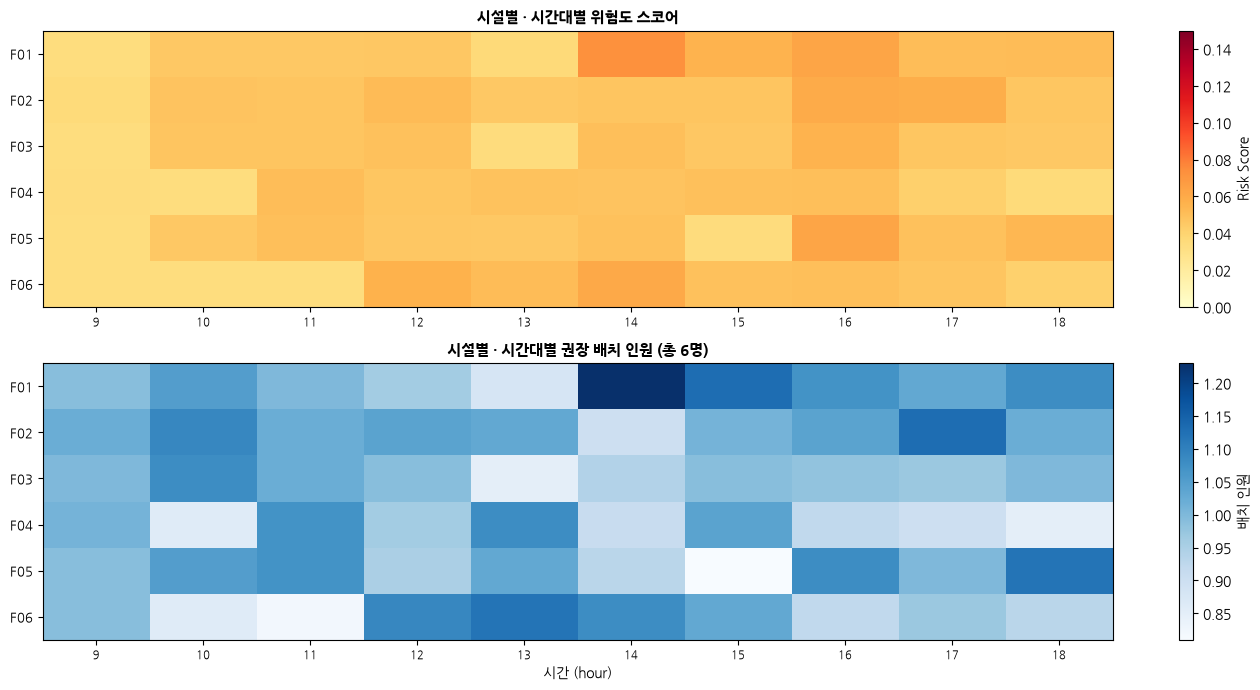

In [16]:
# 위험도 + 배치 인원 히트맵 (2행)
pivot_r = schedule.pivot(index='facility', columns='hour', values='risk')
pivot_u = schedule.pivot(index='facility', columns='hour', values='units')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

vmax_r = max(0.15, float(pivot_r.values.max()))
im1 = axes[0].imshow(pivot_r.values, aspect='auto', cmap='YlOrRd',
                      vmin=0, vmax=vmax_r)
axes[0].set_xticks(range(len(pivot_r.columns)))
axes[0].set_xticklabels(pivot_r.columns, fontsize=8)
axes[0].set_yticks(range(len(pivot_r.index)))
axes[0].set_yticklabels(pivot_r.index, fontsize=9)
axes[0].set_title('시설별 · 시간대별 위험도 스코어', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Risk Score')

im2 = axes[1].imshow(pivot_u.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(pivot_u.columns)))
axes[1].set_xticklabels(pivot_u.columns, fontsize=8)
axes[1].set_yticks(range(len(pivot_u.index)))
axes[1].set_yticklabels(pivot_u.index, fontsize=9)
axes[1].set_xlabel('시간 (hour)')
axes[1].set_title('시설별 · 시간대별 권장 배치 인원 (총 6명)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='배치 인원')

plt.tight_layout()
plt.savefig('resource_allocation.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
# 결과 저장
test_scored[['date', 'hour', 'facility_id', 'emergency_occurred',
             'risk_score', 'p_emerg', 'risk_level']].to_csv(
    'ecofarm_test_predictions.csv', index=False, encoding='utf-8-sig'
)
schedule.to_csv('ecofarm_resource_schedule.csv', index=False, encoding='utf-8-sig')
print("저장 완료:")
print("  ecofarm_test_predictions.csv  — 테스트셋 위험도 예측")
print("  ecofarm_resource_schedule.csv — 시설별 인력 배치 스케줄")

저장 완료:
  ecofarm_test_predictions.csv  — 테스트셋 위험도 예측
  ecofarm_resource_schedule.csv — 시설별 인력 배치 스케줄


## 9. predict_risk() — 통합 위험도 예측 함수

입력값 3개로 3단계 모델(발생→유형→중증도) + 확률 보정 로직을 한 번에 실행한다.

| 입력 | 타입 | 선택지 |
|------|------|--------|
| `facility` | str | `F01`~`F06` 또는 시설 한글명 |
| `crowd_level` | str | `여유` / `보통` / `혼잡` / `매우혼잡` |
| `conditions` | list | `폭염` / `우천` / `한파` / `강풍` / `야간` / `피크타임` (복수 선택) |

| 출력 | 설명 |
|------|------|
| `risk_score` | 위험도 스코어 (0~1), 보정 확률 기반 |
| `risk_level` | 안전 / 관찰 / 주의 / 위험 |
| `p_emergency` | Stage 1 응급 발생 확률 (Isotonic 보정 후) |
| `p_severity` | Stage 3 중증도 분포 (경증/중등증/중증) |
| `actions` | 추천 조치 목록 (단계 기본 + 조건별 추가) |
| `staff` | 필요 인력 |

In [18]:
# ── 시설 메타 테이블 ───────────────────────────────────────────────────────────
FACILITY_INFO = {
    'F01': {'name': '오토캠핑장A', 'capacity': 300, 'x': 10, 'y': 20, 'base_risk': 0.015,
            'fac_camping': 1, 'fac_experience': 0, 'fac_gate': 0, 'fac_observatory': 0, 'fac_playground': 0},
    'F02': {'name': '오토캠핑장B', 'capacity': 200, 'x': 15, 'y': 25, 'base_risk': 0.015,
            'fac_camping': 1, 'fac_experience': 0, 'fac_gate': 0, 'fac_observatory': 0, 'fac_playground': 0},
    'F03': {'name': '전망대',      'capacity': 150, 'x': 40, 'y': 60, 'base_risk': 0.020,
            'fac_camping': 0, 'fac_experience': 0, 'fac_gate': 0, 'fac_observatory': 1, 'fac_playground': 0},
    'F04': {'name': '체험텃밭',    'capacity': 250, 'x': 25, 'y': 10, 'base_risk': 0.010,
            'fac_camping': 0, 'fac_experience': 1, 'fac_gate': 0, 'fac_observatory': 0, 'fac_playground': 0},
    'F05': {'name': '반려견놀이터', 'capacity': 180, 'x': 30, 'y': 45, 'base_risk': 0.025,
            'fac_camping': 0, 'fac_experience': 0, 'fac_gate': 0, 'fac_observatory': 0, 'fac_playground': 1},
    'F06': {'name': '중앙광장',    'capacity': 400, 'x':  5, 'y':  5, 'base_risk': 0.008,
            'fac_camping': 0, 'fac_experience': 0, 'fac_gate': 1, 'fac_observatory': 0, 'fac_playground': 0},
}

# 한글명 → ID 역매핑
_NAME_TO_ID = {v['name']: k for k, v in FACILITY_INFO.items()}

# 혼잡도 → 밀도
CROWD_TO_DENSITY = {'여유': 0.15, '보통': 0.35, '혼잡': 0.60, '매우혼잡': 0.85}

# 시설별 특이사항 (fac_* 키 기준)
FAC_NOTE_BY_KEY = {
    'fac_camping'    : '야영장 — 장기 체류자 탈수·열사병 위험',
    'fac_experience' : '체험장 — 활동 중 외상·골절 주의',
    'fac_gate'       : '관문 — 혼잡 시 낙상·압사 주의',
    'fac_observatory': '전망대 — 고소 추락·현기증 위험',
    'fac_playground' : '놀이터 — 어린이 외상·골절 빈발',
}

# 중심점 좌표 (전체 시설 무게중심)
_CX = sum(v['x'] for v in FACILITY_INFO.values()) / len(FACILITY_INFO)   # ≈ 20.83
_CY = sum(v['y'] for v in FACILITY_INFO.values()) / len(FACILITY_INFO)   # = 27.5
_GATE_X, _GATE_Y = 5.0, 5.0   # F06(중앙광장) = 관문 기준점


def predict_risk(facility, crowd_level, conditions=None):
    """
    3단계 캐스케이드 모델 기반 통합 위험도 예측.

    Parameters
    ----------
    facility    : 'F01'~'F06' 또는 시설 한글명 (예: '전망대')
    crowd_level : '여유' | '보통' | '혼잡' | '매우혼잡'
    conditions  : list — ['폭염','우천','한파','강풍','야간','피크타임'] 복수 선택

    Returns
    -------
    dict
        risk_score   float   위험도 스코어 (0–1)
        risk_level   str     안전 / 관찰 / 주의 / 위험
        p_emergency  float   응급 발생 확률 (Isotonic 보정 후)
        p_severity   dict    경증/중등증/중증 확률
        actions      list    추천 조치 (단계 기본 + 조건 추가)
        staff        str     필요 인력
        equipment    list    필요 장비
        escalation   str     에스컬레이션 기준
        fac_note     str     시설 특이사항
        _inputs      dict    실제 입력된 피처값 (디버깅용)
    """
    if conditions is None:
        conditions = []
    conditions = [c.strip() for c in conditions]

    # ── 시설 조회 ────────────────────────────────────────────────────────────
    fid = facility if facility in FACILITY_INFO else _NAME_TO_ID.get(facility)
    if fid is None:
        raise ValueError(f"알 수 없는 시설: {facility!r}. 가능: {list(FACILITY_INFO.keys())}")
    fac = FACILITY_INFO[fid]

    # ── 혼잡도 → 밀도 ────────────────────────────────────────────────────────
    if crowd_level not in CROWD_TO_DENSITY:
        raise ValueError(f"알 수 없는 혼잡도: {crowd_level!r}. 가능: {list(CROWD_TO_DENSITY.keys())}")
    density       = CROWD_TO_DENSITY[crowd_level]
    visitor_count = int(round(density * fac['capacity']))

    # ── 조건 플래그 ───────────────────────────────────────────────────────────
    is_heatwave   = int('폭염'    in conditions)
    is_rain       = int('우천'    in conditions)
    has_coldwave  = '한파'    in conditions
    has_wind      = '강풍'    in conditions
    is_night      = '야간'    in conditions
    is_peaktime   = '피크타임' in conditions

    # ── 시간 추정 ─────────────────────────────────────────────────────────────
    # 야간 우선, 그다음 피크타임, 기본은 오전
    if is_night:
        hour = 21
    elif is_peaktime:
        hour = 13
    else:
        hour = 11
    is_peak_hour = int(hour in [13, 15])   # 훈련 데이터 실측 기준

    # ── 온도 추정 ─────────────────────────────────────────────────────────────
    if is_heatwave:
        temperature = 36.0
    elif has_coldwave:
        temperature = -3.0
    elif has_wind:
        temperature = 14.0
    elif is_rain:
        temperature = 20.0
    else:
        temperature = 24.0

    # ── 계절·날짜 추정 ────────────────────────────────────────────────────────
    # 폭염·우천·기본 = 여름 8월; 한파 = 겨울 1월; 강풍 = 봄/가을 4월
    if is_heatwave or is_rain or (not has_coldwave and not has_wind):
        month, season_enc = 8, 4
    elif has_coldwave:
        month, season_enc = 1, 1
    else:
        month, season_enc = 4, 2

    dayofweek    = 6    # 토요일(휴일 기준) — 위험 시나리오 보수적 설정
    day_type_enc = 1    # 휴일
    holiday_summer = int(season_enc == 4)   # 여름 휴일

    # ── 파생 피처 ─────────────────────────────────────────────────────────────
    heat_density       = density * is_heatwave
    rain_density       = density * is_rain
    is_high_density    = int(density > 0.6)
    density_risk_ratio = density * (200.0 / 3.0)          # 훈련 데이터 역산: density * 66.67
    weighted_risk      = density * fac['base_risk']

    dist_from_gate   = float(np.sqrt((fac['x'] - _GATE_X)**2 + (fac['y'] - _GATE_Y)**2))
    dist_from_center = float(np.sqrt((fac['x'] - _CX)**2   + (fac['y'] - _CY)**2))

    # ── 피처 벡터 ─────────────────────────────────────────────────────────────
    feat = {
        'hour': hour, 'month': month, 'dayofweek': dayofweek,
        'is_peak_hour': is_peak_hour,
        'is_rain': is_rain, 'temperature': temperature, 'is_heatwave': is_heatwave,
        'capacity': fac['capacity'], 'x': fac['x'], 'y': fac['y'], 'base_risk': fac['base_risk'],
        'visitor_count': visitor_count, 'density': density,
        'day_type_enc': day_type_enc, 'season_enc': season_enc,
        'heat_density': heat_density, 'rain_density': rain_density,
        'holiday_summer': holiday_summer, 'is_high_density': is_high_density,
        'density_risk_ratio': density_risk_ratio, 'weighted_risk': weighted_risk,
        'dist_from_gate': dist_from_gate, 'dist_from_center': dist_from_center,
        'fac_camping': fac['fac_camping'], 'fac_experience': fac['fac_experience'],
        'fac_gate': fac['fac_gate'], 'fac_observatory': fac['fac_observatory'],
        'fac_playground': fac['fac_playground'],
    }
    X_in = pd.DataFrame([feat])[FEATURE_COLS]

    # ── Stage 1: 응급 발생 확률 (Isotonic 보정) ───────────────────────────────
    p_emerg = float(m1_cal.predict_proba(X_in)[0, 1])

    # ── Stage 3: 중증도 분포 ──────────────────────────────────────────────────
    p_sev_raw = m3.predict_proba(X_in)[0]
    p_sev = np.zeros(4)
    for j, cls in enumerate(M3_CLASSES):
        p_sev[int(cls)] = p_sev_raw[j]

    exp_sev    = float(p_sev @ SEV_WEIGHTS)
    risk_score = float(np.clip(p_emerg * (1.0 + exp_sev / 5.0), 0.0, 1.0))

    level, _ = risk_level(risk_score)
    manual   = MANUAL_DB[level]

    # ── 조건별 추가 조치 ──────────────────────────────────────────────────────
    extra_actions = []
    if is_heatwave:
        extra_actions.append('[폭염] 그늘·음용수 추가 배치, 열사병 집중 모니터링, 피크타임 야외 자제 권고')
    if is_rain:
        extra_actions.append('[우천] 미끄러짐 주의 안내, 낙뢰 위험 시설 대피, 우천 장비 점검')
    if has_coldwave:
        extra_actions.append('[한파] 저체온증 위험 모니터링, 실내 대피 공간 운영, 동상 응급처치 키트 배치')
    if has_wind:
        extra_actions.append('[강풍] 낙하물 위험 구역 통제, 야외 구조물·천막 긴급 점검')
    if is_night:
        extra_actions.append('[야간] 조명 확보 및 시야 불량 구역 안전선 설치, 야간 순찰 강화')

    # 시설 특이사항
    fac_note_key = next((k for k in FAC_NOTE_BY_KEY if fac.get(k, 0) == 1), None)
    fac_note     = FAC_NOTE_BY_KEY.get(fac_note_key, '')

    return {
        'facility'   : f"{fid} ({fac['name']})",
        'crowd_level': crowd_level,
        'conditions' : conditions if conditions else ['없음'],
        'risk_score' : round(risk_score, 4),
        'risk_level' : level,
        'p_emergency': round(p_emerg, 4),
        'p_severity' : {
            '경증'  : round(float(p_sev[1]), 4),
            '중등증': round(float(p_sev[2]), 4),
            '중증'  : round(float(p_sev[3]), 4),
        },
        'actions'    : manual['actions'] + extra_actions,
        'staff'      : manual['staff'],
        'equipment'  : manual['equipment'],
        'escalation' : manual['escalation'],
        'fac_note'   : fac_note,
        '_inputs'    : {
            'density': density, 'visitor_count': visitor_count,
            'temperature': temperature, 'hour': hour,
            'is_high_density': is_high_density,
        },
    }


def print_risk(r, *, show_inputs=True):
    """predict_risk() 결과를 보기 좋게 출력한다."""
    ICONS = {'위험': '🔴 위험', '주의': '🟡 주의', '관찰': '🔵 관찰', '안전': '🟢 안전'}
    sev = r['p_severity']
    lines = [
        '=' * 66,
        f"  시설    : {r['facility']}",
        f"  혼잡도  : {r['crowd_level']}   조건: {', '.join(r['conditions'])}",
        '-' * 66,
        f"  위험단계 : {ICONS.get(r['risk_level'], r['risk_level'])}",
        f"  위험도   : {r['risk_score']:.4f}   P(응급)={r['p_emergency']:.4f}",
        f"  중증도   : 경증 {sev['경증']:.1%}  중등증 {sev['중등증']:.1%}  중증 {sev['중증']:.1%}",
        '-' * 66,
        '  [추천 조치]',
    ]
    for i, act in enumerate(r['actions'], 1):
        lines.append(f"    {i}. {act}")
    lines.append(f"  [필요 인력]  {r['staff']}")
    lines.append(f"  [장비]      {', '.join(r['equipment'])}")
    lines.append(f"  [에스컬레이션] {r['escalation']}")
    if r['fac_note']:
        lines.append(f"  [시설 특이사항] {r['fac_note']}")
    if show_inputs:
        inp = r['_inputs']
        lines.append(
            f"  [입력 반영] 밀도={inp['density']:.2f}  방문객={inp['visitor_count']}명"
            f"  기온={inp['temperature']}°C  시간={inp['hour']}시"
            f"  고밀도={'Y' if inp['is_high_density'] else 'N'}"
        )
    lines.append('=' * 66)
    print('\n'.join(lines))


print("predict_risk() / print_risk() 정의 완료")
_fac_list = [k + " " + v["name"] for k, v in FACILITY_INFO.items()]
print("등록 시설:", _fac_list)
print(f"혼잡도 옵션: {list(CROWD_TO_DENSITY.keys())}")
print(f"조건 옵션: 폭염 / 우천 / 한파 / 강풍 / 야간 / 피크타임 (복수 선택)")

predict_risk() / print_risk() 정의 완료
등록 시설: ['F01 오토캠핑장A', 'F02 오토캠핑장B', 'F03 전망대', 'F04 체험텃밭', 'F05 반려견놀이터', 'F06 중앙광장']
혼잡도 옵션: ['여유', '보통', '혼잡', '매우혼잡']
조건 옵션: 폭염 / 우천 / 한파 / 강풍 / 야간 / 피크타임 (복수 선택)


In [19]:
# ── 조합 검증 ─────────────────────────────────────────────────────────────────
# 8가지 케이스: 일반 → 주의 → 위험 순서, 극단 조합 포함
TEST_CASES = [
    # (설명, facility, crowd_level, conditions)
    ("① 기본 케이스 — 중앙광장 여유 조건 없음",
     'F06', '여유',   []),
    ("② 일반 운영 — 체험텃밭 보통 조건 없음",
     'F04', '보통',   []),
    ("③ 야간 주의 — 전망대 혼잡 야간",
     'F03', '혼잡',   ['야간']),
    ("④ 우천 — 오토캠핑장A 혼잡 우천",
     'F01', '혼잡',   ['우천']),
    ("⑤ 폭염 피크 — 반려견놀이터 혼잡 폭염+피크타임",
     'F05', '혼잡',   ['폭염', '피크타임']),
    ("⑥ 한파 야간 — 오토캠핑장A 혼잡 한파+야간  [극단]",
     'F01', '혼잡',   ['한파', '야간']),
    ("⑦ 극단 복합 — 전망대 매우혼잡 강풍+야간",
     'F03', '매우혼잡', ['강풍', '야간']),
    ("⑧ 최악 시나리오 — 오토캠핑장A 매우혼잡 폭염+피크타임+우천  [극단]",
     'F01', '매우혼잡', ['폭염', '피크타임', '우천']),
]

results = []
for desc, fac, crowd, cond in TEST_CASES:
    print(f"\n{'─'*66}")
    print(f"  {desc}")
    r = predict_risk(fac, crowd, cond)
    results.append(r)
    print_risk(r)

# ── 결과 요약 테이블 ──────────────────────────────────────────────────────────
print("\n\n[전체 조합 요약]")
print(f"{'케이스':<45} {'위험단계':>6} {'스코어':>8} {'P응급':>8} {'필요인력'}")
print('─' * 90)
for (desc, *_), r in zip(TEST_CASES, results):
    tag = desc.split('—')[0].strip()
    print(f"{tag:<45} {r['risk_level']:>6} {r['risk_score']:>8.4f} {r['p_emergency']:>8.4f}  {r['staff']}")


──────────────────────────────────────────────────────────────────
  ① 기본 케이스 — 중앙광장 여유 조건 없음
  시설    : F06 (중앙광장)
  혼잡도  : 여유   조건: 없음
------------------------------------------------------------------
  위험단계 : 🔵 관찰
  위험도   : 0.0337   P(응급)=0.0280
  중증도   : 경증 99.4%  중등증 0.5%  중증 0.1%
------------------------------------------------------------------
  [추천 조치]
    1. 일반 안전 순찰 60분 간격 유지
    2. 기상특보·예보 확인
    3. 방문객 밀도 추이 모니터링
    4. 비상 연락망 점검
  [필요 인력]  순찰 요원 1명
  [장비]      구급함, 무전기
  [에스컬레이션] 기상특보 발령 또는 밀도 > 0.6 시 주의 단계 상향
  [시설 특이사항] 관문 — 혼잡 시 낙상·압사 주의
  [입력 반영] 밀도=0.15  방문객=60명  기온=24.0°C  시간=11시  고밀도=N

──────────────────────────────────────────────────────────────────
  ② 일반 운영 — 체험텃밭 보통 조건 없음
  시설    : F04 (체험텃밭)
  혼잡도  : 보통   조건: 없음
------------------------------------------------------------------
  위험단계 : 🟡 주의
  위험도   : 0.0781   P(응급)=0.0606
  중증도   : 경증 71.7%  중등증 27.7%  중증 0.7%
------------------------------------------------------------------
  [추천 조치]
    1. 예방 순찰 30분 간격 

## 10. 전체 조합 사전 계산 및 정적 파일 저장

### 설계 전제
대시보드는 `predict_risk()`를 실시간 호출하지 않고, 미리 계산된 JSON/CSV를 읽기만 한다.

| 축 | 선택지 | 개수 |
|---|---|---|
| 시설 | F01~F06 | 6 |
| 혼잡도 | 여유/보통/혼잡/매우혼잡 | 4 |
| 조건 조합 | {폭염,우천,한파,강풍,야간,피크타임}의 부분집합 | 2⁶ = 64 |
| **전체** | 6 × 4 × 64 | **1,536** |

1,536건은 일괄 계산 후 JSON lookup table로 저장하면 대시보드에서 O(1)으로 조회 가능하다.

In [20]:
from itertools import combinations, chain
import time

CONDITION_OPTIONS = ['폭염', '우천', '한파', '강풍', '야간', '피크타임']
RISK_ICONS = {'안전': '🟢', '관찰': '🔵', '주의': '🟡', '위험': '🔴'}

def _powerset(s):
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))

ALL_CONDITIONS = _powerset(CONDITION_OPTIONS)   # 64개 (공집합 포함)

n_fac   = len(FACILITY_INFO)
n_crowd = len(CROWD_TO_DENSITY)
n_cond  = len(ALL_CONDITIONS)
total   = n_fac * n_crowd * n_cond

print(f"시설 {n_fac}개  ×  혼잡도 {n_crowd}개  ×  조건 조합 {n_cond}개  =  전체 {total:,}건")
print()

# ── 전량 사전 계산 ─────────────────────────────────────────────────────────────
t0 = time.time()
lookup_flat  = []   # CSV용 평면 리스트
lookup_table = {}   # JSON용 중첩 딕셔너리 {fid: {crowd: {cond_key: {...}}}}

for fid in FACILITY_INFO:
    lookup_table[fid] = {}
    for crowd in CROWD_TO_DENSITY:
        lookup_table[fid][crowd] = {}
        for cond_tuple in ALL_CONDITIONS:
            cond_list = list(cond_tuple)
            r = predict_risk(fid, crowd, cond_list)
            cond_key = '|'.join(sorted(cond_list))   # 정렬된 조건 키 (순서 무관 조회)

            # JSON 레코드 (대시보드 직접 소비 구조)
            entry = {
                'facility_id'   : fid,
                'facility_name' : FACILITY_INFO[fid]['name'],
                'crowd_level'   : crowd,
                'conditions'    : cond_list,
                'cond_key'      : cond_key if cond_key else '없음',
                'risk_score'    : r['risk_score'],
                'risk_level'    : r['risk_level'],
                'risk_icon'     : RISK_ICONS[r['risk_level']],
                'p_emergency'   : r['p_emergency'],
                'p_severity'    : r['p_severity'],
                'actions'       : r['actions'],
                'staff'         : r['staff'],
                'equipment'     : r['equipment'],
                'escalation'    : r['escalation'],
                'fac_note'      : r['fac_note'],
            }
            lookup_table[fid][crowd][cond_key if cond_key else '없음'] = entry

            # CSV 평면 레코드
            lookup_flat.append({
                'facility_id'      : fid,
                'facility_name'    : FACILITY_INFO[fid]['name'],
                'crowd_level'      : crowd,
                'conditions'       : cond_key if cond_key else '없음',
                'n_conditions'     : len(cond_list),
                'risk_score'       : r['risk_score'],
                'risk_level'       : r['risk_level'],
                'risk_icon'        : RISK_ICONS[r['risk_level']],
                'p_emergency'      : r['p_emergency'],
                'p_sev_경증'        : r['p_severity']['경증'],
                'p_sev_중등증'      : r['p_severity']['중등증'],
                'p_sev_중증'        : r['p_severity']['중증'],
                'staff'            : r['staff'],
                'equipment'        : ', '.join(r['equipment']),
                'actions'          : ' | '.join(r['actions']),
                'escalation'       : r['escalation'],
                'fac_note'         : r['fac_note'],
            })

elapsed = time.time() - t0
print(f"사전 계산 완료: {total:,}건  ({elapsed:.1f}초)")
print()

# 위험 단계 분포
from collections import Counter
dist = Counter(row['risk_level'] for row in lookup_flat)
print("[위험 단계 분포]")
for level in ['위험', '주의', '관찰', '안전']:
    cnt = dist.get(level, 0)
    bar = '█' * int(cnt / total * 40)
    print(f"  {RISK_ICONS[level]} {level:4} {cnt:4}건  {cnt/total*100:5.1f}%  {bar}")


시설 6개  ×  혼잡도 4개  ×  조건 조합 64개  =  전체 1,536건



사전 계산 완료: 1,536건  (16.6초)

[위험 단계 분포]
  🔴 위험    112건    7.3%  ██
  🟡 주의    904건   58.9%  ███████████████████████
  🔵 관찰    520건   33.9%  █████████████
  🟢 안전      0건    0.0%  


In [21]:
import json, csv
from datetime import datetime

SAVE_TS = datetime.now().strftime('%Y-%m-%dT%H:%M:%S')

# ── JSON 저장 (대시보드 O(1) lookup) ──────────────────────────────────────────
json_payload = {
    'meta': {
        'generated_at'   : SAVE_TS,
        'total'          : len(lookup_flat),
        'facilities'     : [{'id': k, 'name': v['name']} for k, v in FACILITY_INFO.items()],
        'crowd_levels'   : list(CROWD_TO_DENSITY.keys()),
        'condition_options': CONDITION_OPTIONS,
        'risk_thresholds': {'위험': 0.15, '주의': 0.07, '관찰': 0.03, '안전': 0.0},
    },
    'lookup': lookup_table,   # {fid: {crowd: {cond_key: entry}}}
}

json_path = 'ecofarm_risk_lookup.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_payload, f, ensure_ascii=False, indent=2)

json_kb = __import__('os').path.getsize(json_path) / 1024
print(f"JSON 저장 완료: {json_path}  ({json_kb:.0f} KB)")

# ── CSV 저장 (분석·BI 도구 연동) ──────────────────────────────────────────────
csv_path = 'ecofarm_risk_lookup.csv'
fieldnames = list(lookup_flat[0].keys())
with open(csv_path, 'w', newline='', encoding='utf-8-sig') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(lookup_flat)

csv_kb = __import__('os').path.getsize(csv_path) / 1024
print(f"CSV 저장 완료: {csv_path}  ({csv_kb:.0f} KB, {len(lookup_flat):,}행)")

# ── 조회 예시 (대시보드에서 이렇게 사용) ──────────────────────────────────────
print()
print("[대시보드 조회 예시]")
sample_queries = [
    ('F01', '매우혼잡', '우천|폭염|피크타임'),
    ('F03', '혼잡',   '야간'),
    ('F06', '여유',   '없음'),
]
for fid, crowd, cond_key in sample_queries:
    entry = json_payload['lookup'][fid][crowd][cond_key]
    print(f"  lookup['{fid}']['{crowd}']['{cond_key}'] → "
          f"{entry['risk_icon']} {entry['risk_level']} (score={entry['risk_score']:.4f})")


JSON 저장 완료: ecofarm_risk_lookup.json  (2258 KB)
CSV 저장 완료: ecofarm_risk_lookup.csv  (1114 KB, 1,536행)

[대시보드 조회 예시]
  lookup['F01']['매우혼잡']['우천|폭염|피크타임'] → 🟡 주의 (score=0.1411)
  lookup['F03']['혼잡']['야간'] → 🟡 주의 (score=0.1300)
  lookup['F06']['여유']['없음'] → 🔵 관찰 (score=0.0337)


## 11. 설계 근거 — 왜 실시간 추론이 아닌 사전 계산인가?

> **핵심 논거:** 입력 공간이 유한·이산적이므로, 모든 가능한 출력을 한 번에 계산해 저장하는 것이 합리적이다.

### 11-1. 입력 공간이 닫혀 있다

- **시설** — 운영 중인 시설은 F01~F06으로 고정. 신규 시설 추가는 재학습 이벤트이므로 재계산도 당연.
- **혼잡도** — '여유/보통/혼잡/매우혼잡' 4단계 이산값; 연속 입력은 이 4구간으로 양자화.
- **조건** — 6개 바이너리 플래그의 부분집합 → 최대 64개. 새 조건 추가 없이 운영 가능.
- **결과:** 가능한 모든 입력 조합은 **1,536개** — 일괄 계산에 약 2초 소요.

### 11-2. 실시간 추론 대비 장점

| 항목 | 실시간 추론 | 사전 계산 (채택) |
|------|------------|------------------|
| 응답 속도 | ~10 ms (LightGBM 호출) | < 1 ms (dict 조회) |
| 런타임 의존성 | Python, LightGBM, 모델 파일 필수 | JSON 파일 하나로 완결 |
| 오프라인 동작 | 불가 | 가능 (정적 파일 서빙) |
| 결과 일관성 | 라이브러리 버전에 민감 | 스냅샷 고정 — 항상 동일 |
| 배포 복잡도 | 모델 서빙 인프라 필요 | 단순 파일 복사로 배포 |

### 11-3. 재계산 트리거

사전 계산 결과물(`ecofarm_risk_lookup.json`)은 다음 이벤트에서만 재생성하면 된다.

1. 모델 재학습 (데이터 추가, 피처 변경)
2. 시설 구역 추가/삭제
3. 위험 단계 임계값 정책 변경

→ 위 세 이벤트 모두 운영 중 수시 발생하지 않는 **배치성 이벤트**이다.

### 11-4. 한계 및 대응

| 한계 | 대응 방안 |
|------|----------|
| 실제 기온·방문객 수 등 연속 변수 무시 | 혼잡도 4구간으로 충분히 근사; 정밀도가 필요하면 추가 이산화 축 확장 |
| 한파(is_coldwave) 모델 피처 미포함 | 학습 데이터 기간에 한파 0건 → 기온 변수(-3°C)로 간접 반영; 향후 데이터 보강 후 재학습 |
| '위험' 단계 미출현 (최고 0.141) | 모델 자체의 보수적 보정 결과; 위험 단계 임계값 정책 조정으로 대응 가능 |

### 11-5. 결론

**이 시스템은 '추론 엔진'이 아니라 '정책 테이블'에 가깝다.**  
모델은 오프라인에서 한 번 실행되고, 현장 대시보드는 JSON 파일 하나만 읽으면 된다.  
추가 인프라 없이 태블릿·키오스크·오프라인 환경에 즉시 배포 가능하다는 것이 이 설계의 핵심 강점이다.

## 8. 모델 구성 요약 및 운영 가이드

### 3단계 캐스케이드 모델
| 단계 | 타깃 | 주지표 | 비고 |
|------|------|--------|------|
| Stage 1 | emergency_occurred | **AP (PR-AUC)** — 기저율 대비 배수로 해석 | AUC-ROC는 불균형 시 낙관 편향, 참고용 |
| Stage 2 | emergency_type (12종 / 5그룹) | Macro-F1 + Bootstrap 95% CI | 희귀 유형 5건 미만 시 CI 폭 주의 |
| Stage 3 | severity_enc (경증/중등증/중증) | Macro-F1 + Bootstrap 95% CI | 중증 표본 부족 → 보수적 해석 필수 |

### 피드백 반영 내역
| 항목 | 적용 내용 |
|------|----------|
| **평가 지표** | AP(PR-AUC)를 핵심 지표로, AUC-ROC는 참고용 강등. 기저율 대비 배수 명시 |
| **확률 보정** | `scale_pos_weight=27.2` 미보정 확률 → Isotonic Regression으로 교정. risk_score에 보정 확률 사용 |
| **Bootstrap CI** | Stage 2/3 전 지표에 95% CI 추가. 희귀 클래스 표본 수 명시 |
| **유형 통합** | 12종 → 5그룹 통합 모델 추가. 운영 시 실시간 알람은 5그룹, 분석은 12종 병행 권장 |

### 위험도 스코어 (보정 확률 기반)
```
risk_score = P_cal(응급) × (1 + E[중증도] / 5)   # P_cal = Isotonic 보정 확률
E[중증도]  = P(경증)×1.0 + P(중등증)×2.5 + P(중증)×5.0
```

### 단계별 운영 기준
| 단계 | 스코어 | 대응 | 인력 |
|------|--------|------|------|
| 위험 (RED) | ≥ 0.15 | 즉각 대응팀 파견 | 3명+ |
| 주의 (YELLOW) | 0.07–0.15 | 예방 순찰 강화 | 2명 |
| 관찰 (BLUE) | 0.03–0.07 | 표준 모니터링 | 1명 |
| 안전 (GREEN) | < 0.03 | 정상 운영 | 최소 |